In [31]:
import os
import sys
import shutil
import pandas as pd
import numpy as np
import seaborn as sns
from dotenv import load_dotenv
import matplotlib.pyplot as plt
import kagglehub
from pathlib import Path

In [2]:
load_dotenv()

True

In [3]:
current_dir = Path.cwd()
project_root = current_dir.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
    print("done")

done


In [4]:
# data_path = project_root / "data"
# cache_path = kagglehub.dataset_download("kundanbedmutha/exam-score-prediction-dataset")

# for item in Path(cache_path).iterdir():
#     shutil.copy2(item, data_path/item.name)
    
# print("Data Saved")

### So, I have got some data from kaggle and will try to apply higher dimension GMM on this data.

In [5]:
path = project_root / "data" / "Exam_Score_Prediction.csv"
data = pd.read_csv(str(path))

In [6]:
data.head()

,student_id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,1,17,male,diploma,2.78,92.9,yes,7.4,poor,coaching,low,hard,58.9
1,2,23,other,bca,3.37,64.8,yes,4.6,average,online videos,medium,moderate,54.8
2,3,22,male,b.sc,7.88,76.8,yes,8.5,poor,coaching,high,moderate,90.3
3,4,20,other,diploma,0.67,48.4,yes,5.8,average,online videos,low,moderate,29.7
4,5,20,female,diploma,0.89,71.6,yes,9.8,poor,coaching,low,moderate,43.7


### For now I will try keep it simple and focus on only those features that not categorical.

In [7]:
data.shape

(20000, 13)

In [8]:
data.columns

Index(['student_id', 'age', 'gender', 'course', 'study_hours',
       'class_attendance', 'internet_access', 'sleep_hours', 'sleep_quality',
       'study_method', 'facility_rating', 'exam_difficulty', 'exam_score'],
      dtype='object')

In [46]:
data["facility_rating"]

0           low
1        medium
2          high
3           low
4           low
          ...  
19995       low
19996    medium
19997       low
19998    medium
19999    medium
Name: facility_rating, Length: 20000, dtype: object

In [45]:
data.notna().all()

student_id          True
age                 True
gender              True
course              True
study_hours         True
class_attendance    True
internet_access     True
sleep_hours         True
sleep_quality       True
study_method        True
facility_rating     True
exam_difficulty     True
exam_score          True
dtype: bool

In [9]:
training_set = data.iloc[0: int(0.6*len(data))][['age', 'study_hours', 'class_attendance', 'sleep_hours', 'exam_score']]
test_set = data.iloc[int(0.6*len(data)):][['age', 'study_hours', 'class_attendance', 'sleep_hours', 'exam_score']]

In [10]:
training_set.head()

,age,study_hours,class_attendance,sleep_hours,exam_score
0,17,2.78,92.9,7.4,58.9
1,23,3.37,64.8,4.6,54.8
2,22,7.88,76.8,8.5,90.3
3,20,0.67,48.4,5.8,29.7
4,20,0.89,71.6,9.8,43.7


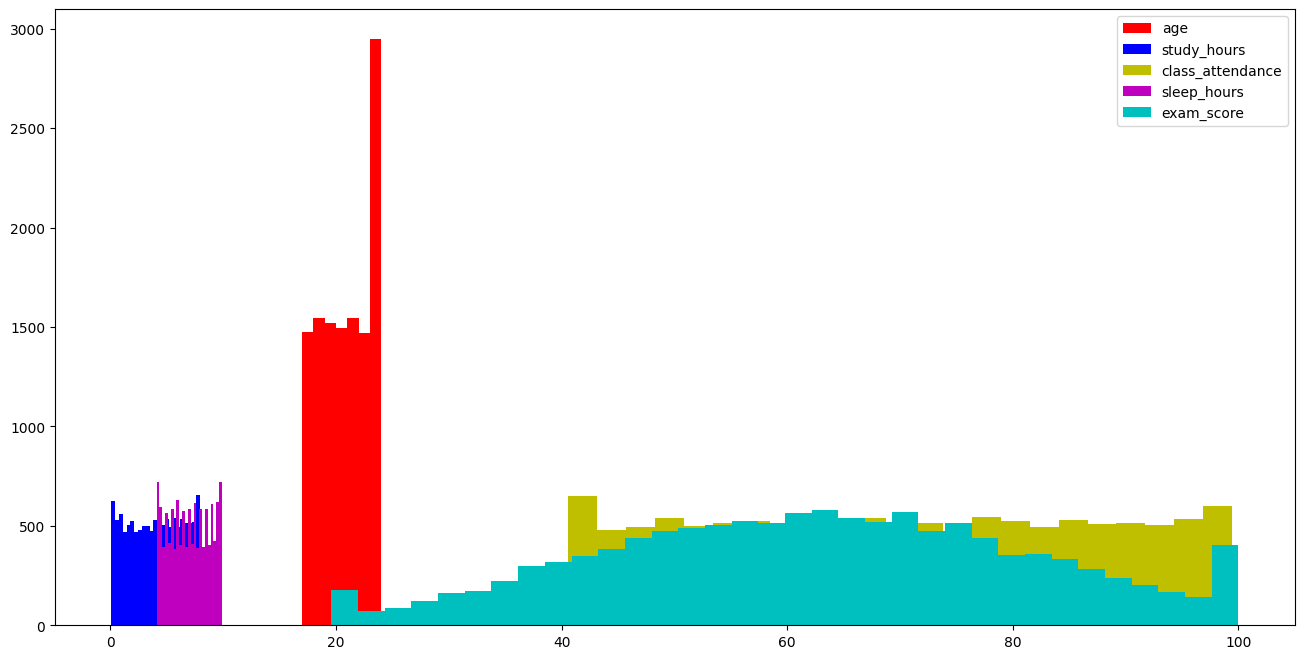

In [11]:
plt.figure(figsize=(16,8))
plt.hist(training_set["age"], color="r", bins='auto', label='age')
plt.hist(training_set["study_hours"], bins='auto', color='b', label='study_hours')
plt.hist(training_set["class_attendance"], color="y", bins='auto', label='class_attendance')
plt.hist(training_set["sleep_hours"], color='m', bins='auto', label='sleep_hours')
plt.hist(training_set["exam_score"], color='c', bins='auto', label='exam_score');

plt.legend()

So, Our data has 5 attributes and is coming from some k sources and we are assuming the every source is guassian and we have to estimate the parameters of those guassian sources

Step 1 we will start with initialization

In [12]:
dim = 5
k = 3
prior = 1/k
initial_means = (training_set.iloc[np.random.randint(low=0, high=len(training_set)-1, size=3)][["age", "study_hours", "class_attendance", 'sleep_hours', "exam_score"]]).to_numpy()

data_cov = np.cov(training_set.T)
initial_cov = np.array([
    data_cov * 0.8 + np.eye(5) * 0.1,
    data_cov * 1.0 + np.eye(5) * 0.1,
    data_cov * 1.2 + np.eye(5) * 0.1,
])

In [13]:
prior

0.3333333333333333

In [14]:
initial_means

array([[20.  ,  6.04, 93.4 ,  4.8 , 79.2 ],
       [23.  ,  7.79, 84.9 ,  6.2 , 87.2 ],
       [19.  ,  7.04, 90.5 ,  9.9 , 93.2 ]])

Step 2: Exceptation step - In this step we will use the our initial guess to calaculate the probabilities for each data point that which data point belongs to which source with what probability

In [15]:
def multivariate_normal_pdf(x: np.array, mean: np.array, cov: np.array):
    """Calculates the pdf for the multivariate normal distribution for given mean, cov and x

    Args:
        x (np.array): (N, d) array - N data points, d features
        mean (d, ) or (1, d): mean of the distribution(vector)
        cov (np.array): (d, d) cov matrix of the diatribution
    """
    N, d = x.shape
    det = np.linalg.det(cov)
    
    if det <= 1e-15:
        cov += np.eye(d) * 1e-6
        det = np.linalg.det(cov)
        
    inv_cov = np.linalg.inv(cov)
    
    diff = x - mean.reshape(1, -1)
    
    exponent = -0.5 * np.sum((diff @ inv_cov) * diff, axis=1)
    
    log_normalization = -0.5 * (d * np.log(2 * np.pi) + np.log(det))
    
    return np.exp(log_normalization + exponent)

In [16]:
# Let's test it
prob = multivariate_normal_pdf(
        x=training_set.iloc[1:10].to_numpy(),
        mean=initial_means[0],
        cov=initial_cov[0]
    )

In [17]:
prob

array([2.51275676e-07, 1.37984173e-07, 3.25923613e-09, 9.15361851e-10,
       2.54503553e-07, 1.50220770e-08, 2.41502761e-09, 2.05150483e-07,
       1.13043169e-10])

In [18]:
# # Now when we have p(x/source) we can find the p(source/x) using bayes rule
# def bayes_prob(x: np.array, means: np.array, cov: np.array, source: int, prior: float = prior) -> float:
#     """Calculates the p(source/x) using bayes theorem

#     Args:
#         x (np.array): data point
#         means (np.array): means of the sources
#         cov (np.array): cov mat of the sources
#         source(int): which source(based on 0 indexing)

#     Returns:
#         float: p(source/x)
#     """
#     num = multivariate_normal_pdf(
#         x=x,
#         mean=means[source].reshape(5,1),
#         cov=cov[source]) * prior
    
#     deno = 0
#     for c in range(cov.shape[0]):
#         deno += multivariate_normal_pdf(
#         x=x,
#         mean=means[c].reshape(5,1),
#         cov=cov[c]) * prior
        
#     return num/deno

In [19]:
def bayes_probs(X: np.array, means: np.array, cov: np.array, prior: float = prior) -> np.array:
    """Gives the bayes_probs for all the sources in a array

    Args:
        X (np.array): data
        means (np.array): means of the sources
        cov (np.array): cov matrix if the sources
        prior (float, optional): uniform. Defaults to prior.

    Returns:
        np.array: bayes_probs for all the sources
    """
    
    likelihoods = np.zeros((len(X), means.shape[0]))
    
    for i in range(means.shape[0]):
        likelihoods[:, i] = multivariate_normal_pdf(
                                x=X,
                                mean=means[i],
                                cov=cov[i],
                            )
        
    weighted_likelihoods = likelihoods * prior
    probs = weighted_likelihoods/(weighted_likelihoods.sum(axis=1, keepdims=True) + 1e-15)
    
    return probs
        

In [20]:
test = bayes_probs(
        X = training_set.iloc[1:10].to_numpy(),
        means=initial_means,
        cov=initial_cov,
    )

test

array([[4.60753251e-01, 5.33287203e-01, 5.95954102e-03],
       [4.83140126e-02, 6.24077344e-01, 3.27608642e-01],
       [5.17387968e-01, 3.11936440e-01, 1.70675115e-01],
       [1.03428294e-02, 2.65343534e-02, 9.63122783e-01],
       [5.08340271e-01, 4.87672136e-01, 3.98758711e-03],
       [2.47777309e-01, 2.64056019e-02, 7.25817039e-01],
       [2.49656313e-02, 6.85981609e-01, 2.89052729e-01],
       [7.50459739e-01, 5.94171977e-02, 1.90123053e-01],
       [8.66841173e-04, 8.27652925e-03, 9.90856607e-01]])

In [21]:
a = 5* np.ones((5, 10))
b = 7 * np.ones((10,))
c = a * b

In [22]:
a.shape, b.shape, c.shape

((5, 10), (10,), (5, 10))

In [23]:
def compute_log_likelihood(X: np.array, means: np.array, cov: np.array, prior: float) -> float:
    """Calcutates the log-likelihood of the GMMs how well they are fitting the data.

    Args:
        X (np.array): data
        means (np.array): means of the sources 
        cov (np.array): covariance matrixes of the sources
        prior (float): prior

    Returns:
        float: total log-likehood
    """
    likelihoods = np.zeros((len(X), means.shape[0]))
    
    for k in range(means.shape[0]):
        likelihoods[:, k] = multivariate_normal_pdf(x=X, mean=means[k], cov=cov[k])
        
    weighted_likelihoods = likelihoods * prior
    total_likelihood = weighted_likelihoods.sum(axis=1)
    
    log_likelihood = np.log(total_likelihood + 1e-15).sum()
    
    return log_likelihood

In [24]:
def higher_dim_expectation_maximization(X: np.array, K: int, iterations: int = 10):
    """Gives you dataframe of how means and cov mat converge as we apply expectation maximization.

        X (np.array): data
        means (np.array): initial means of the assumed sources.
        cov (np.array): initial cov matrixes of the assumed sources.
        iterations (int): no of iteration to run EM.
        prior (float): defaults to uniform
    """
    initial_means = X[np.random.randint(low=0, high=len(X)-1, size=K)]

    data_cov = np.cov(X.T)
    initial_cov = np.array([data_cov * np.random.uniform(low=0, high=2, size=1) + np.eye(X.shape[1]) * 0.1 for _ in range(K)])
    prior = 1/K
    
    current_means = initial_means.copy()
    current_cov = initial_cov.copy()
    
    log_likelihood = []
    
    for i in range(iterations):
        
        ll = compute_log_likelihood(X, current_means, current_cov, prior)
        log_likelihood.append(ll)
        
        bi_s = bayes_probs(X=X, means=current_means, cov=current_cov, prior=prior)
        
        new_means = np.zeros_like(current_means)
        new_cov = np.zeros_like(current_cov)
        
        for source in range(bi_s.shape[1]):
            weight = bi_s[:, source]
            new_means[source, :] = (weight.reshape(-1, 1) * X).sum(axis=0)/(weight.reshape(-1, 1)).sum(axis=0)
            diff = X - new_means[source, :]
            num = (diff.T * weight) @ diff
            den = weight.sum()
            
            new_cov[source] = (num / den) + np.eye(X.shape[1]) * 1e-6
    
        current_means = new_means
        current_cov = new_cov
        # print(f"Iterations {i+1}: Updated means: {current_means}\nUpdated var: {current_cov}")
    return current_means, current_cov, log_likelihood

In [ ]:
updated_means, updated_cov, log_likelihood = higher_dim_expectation_maximization(
    
    X=training_set.values, 
    K=4,
    iterations=20
)

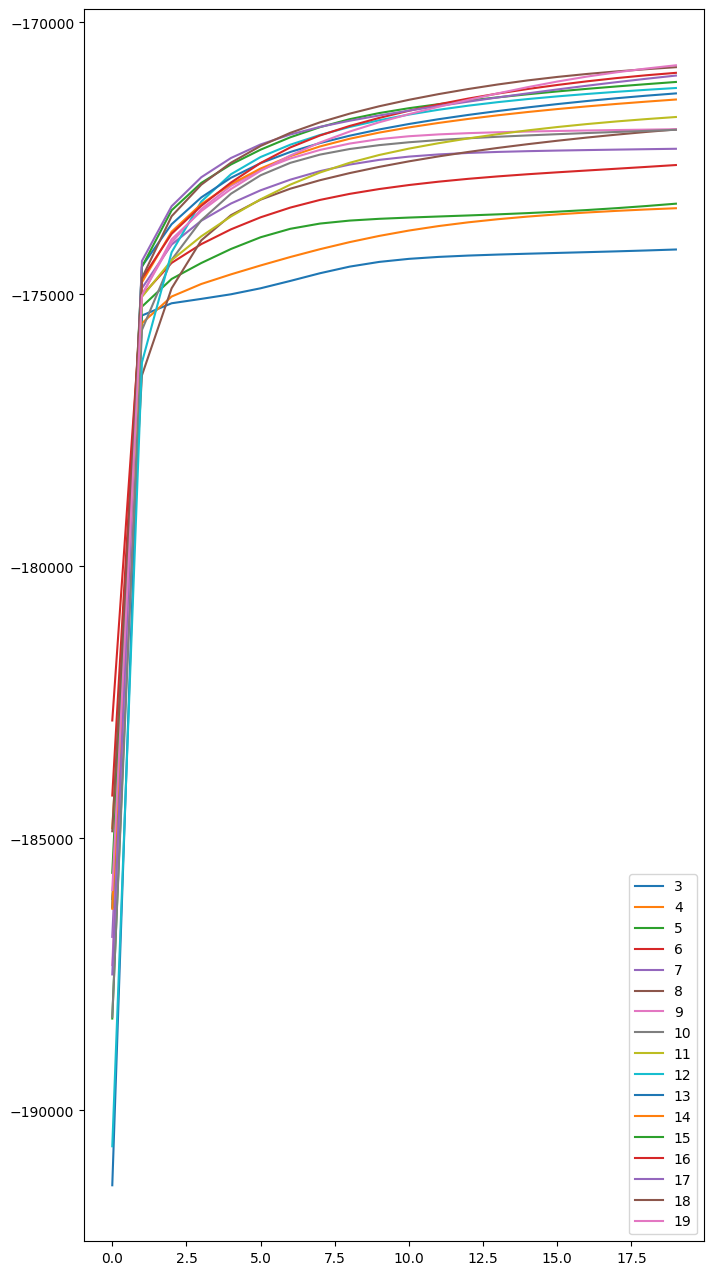

In [108]:
plt.figure(figsize=(8,16))
for k in range(3, 20):
    _, _, ll = higher_dim_expectation_maximization(
        X=training_set.values,
        K=k,
        iterations=20
    )
    plt.plot(ll, label=k)
    
plt.legend()

In [117]:
test_ll = []
for k in range(3, 100):
    u_means, u_covs, _ = higher_dim_expectation_maximization(
        X=training_set.values,
        K=k,
        iterations=20
    )
    
    test_ll.append(compute_log_likelihood(
        X=test_set.values,
        means=u_means,
        cov=u_covs,
        prior=1/k
    ))

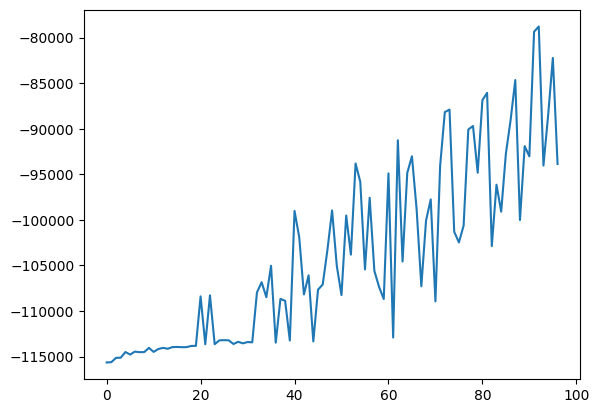

In [118]:
plt.plot(test_ll);

In [26]:
training_set.head()

,age,study_hours,class_attendance,sleep_hours,exam_score
0,17,2.78,92.9,7.4,58.9
1,23,3.37,64.8,4.6,54.8
2,22,7.88,76.8,8.5,90.3
3,20,0.67,48.4,5.8,29.7
4,20,0.89,71.6,9.8,43.7


In [47]:
from tqdm import tqdm
series = []
for i in tqdm(range(20)):
    series.append(higher_dim_expectation_maximization(
        X=training_set.values,
        K=200,
        iterations=20
    ))

100%|██████████| 20/20 [04:21<00:00, 13.06s/it]


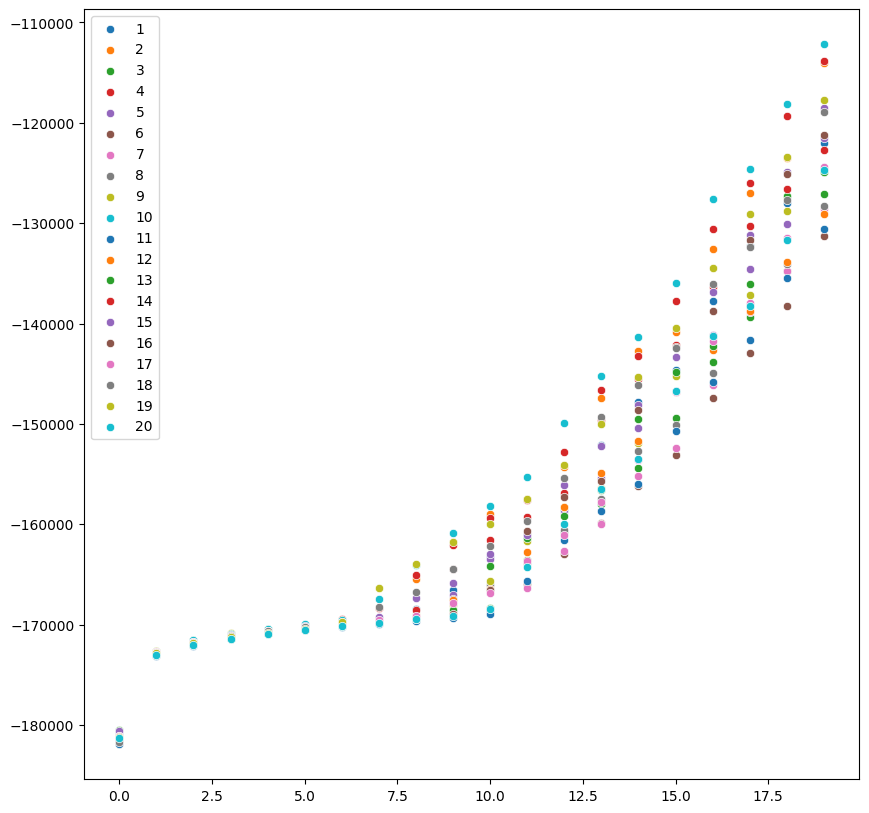

In [48]:
plt.figure(figsize=(10,10))
for i in range(len(series)):
    sns.scatterplot(series[i][-1], label=i+1)
plt.legend();